# demo_a_shepp_linear_rigid

[DataLoader] k-space normalized (rms), scale=1.010733e-01


EspiritCalib: 100%|██████████| 100/100 [00:00<00:00, 1812.16it/s]
/opt/conda/envs/environment_grics/lib/python3.12/site-packages/sigpy/pytorch.py:39: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  tensor = from_dlpack(array.toDlpack())
/home/pyuser/wkdir/src/preprocessing/MotionSimulator.py:145: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  s

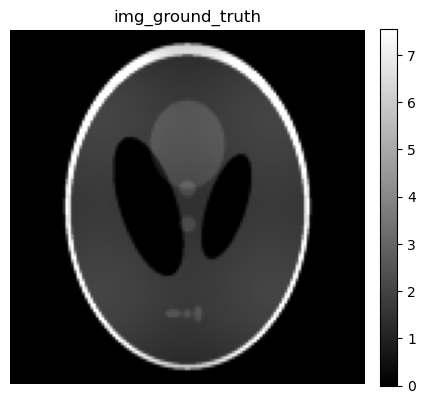

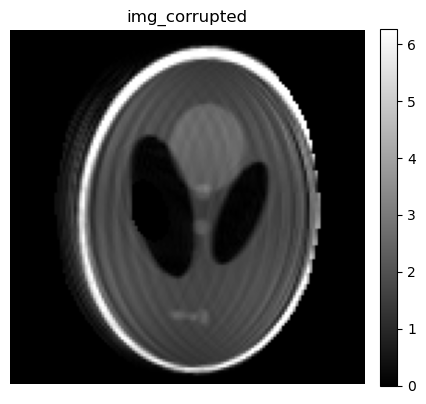

Regularizer proxy scale: 7.513317e-01, lambda_eff=3.756658e-02
CG Iter 1/96, Residual norm: 1.597222e+01, Rel residual: 7.514099e-02
CG Iter 2/96, Residual norm: 8.021075e+00, Rel residual: 3.773498e-02
CG Iter 3/96, Residual norm: 3.354062e+00, Rel residual: 1.577912e-02
CG Iter 4/96, Residual norm: 6.438167e-01, Rel residual: 3.028822e-03
CG Iter 5/96, Residual norm: 6.118138e-02, Rel residual: 2.878265e-04
Regularizer proxy scale: 8.188369e+04, lambda_eff=8.188369e+03
CG Iter 1/64, Residual norm: 2.568746e+01, Rel residual: 6.413765e-01
CG Iter 2/64, Residual norm: 3.551892e-01, Rel residual: 8.868531e-03
CG Iter 3/64, Residual norm: 1.027251e-12, Rel residual: 2.564887e-14
CG Iter 1/96, Residual norm: 1.676949e-02, Rel residual: 7.892289e-05
Regularizer proxy scale: 7.382167e-01, lambda_eff=3.691083e-02
CG Iter 1/96, Residual norm: 1.097228e+01, Rel residual: 4.794417e-02
CG Iter 2/96, Residual norm: 4.943052e+00, Rel residual: 2.159902e-02
CG Iter 3/96, Residual norm: 2.680108e+00

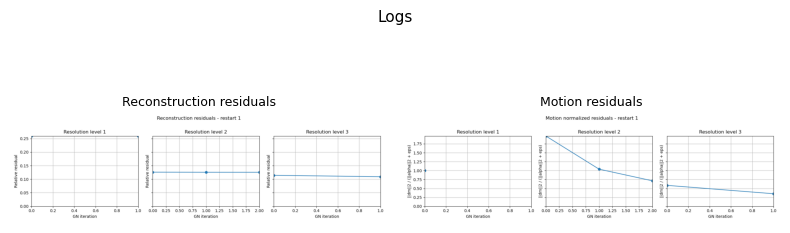

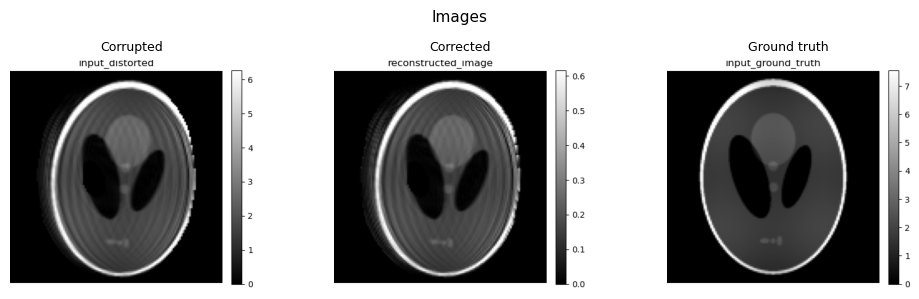

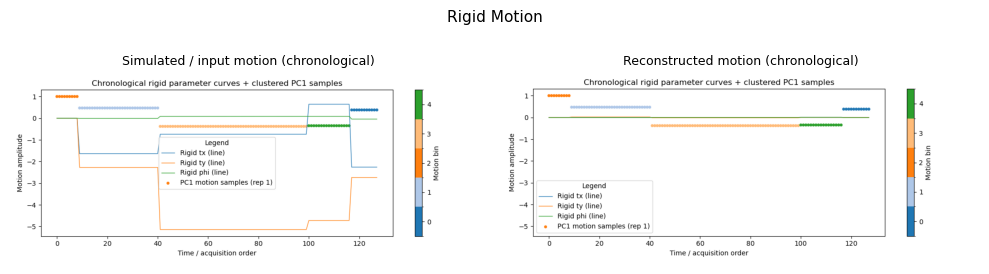

In [2]:
import time
import sys
from pathlib import Path

if "__file__" in globals():
    _REPO_ROOT = Path(__file__).resolve().parents[1]
else:
    _REPO_ROOT = Path.cwd()
sys.path.insert(0, str(_REPO_ROOT))

from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.utils.show_and_save_image import show_and_save_image
from src.utils.notebook_display import display_run_panels
from src.runtime.runtime_setup import initialize_runtime

jupyter_notebook_flag = True


def main():
    params = load_config(
        data_type="shepp-logan",
        shepp_logan_config="config/shepp_logan.toml",
        reconstruction_config="config/reconstruction/rigid_fast.toml",
        sampling_config="config/sampling_simulation/linear.toml",
        motion_simulation_config="config/motion_simulation/rigid.toml",
        overrides={
            "jupyter_notebook_flag": jupyter_notebook_flag,
            "print_to_console": not jupyter_notebook_flag,
        },
    )

    sp_device, t_device = initialize_runtime(params)

    data = DataLoader(params=params, t_device=t_device, sp_device=sp_device)
    show_and_save_image(
        data.image_ground_truth[0],
        "img_ground_truth",
        params.debug_folder,
        flip_for_display=getattr(params, "flip_for_display", params.data_type in {"real-world", "raw-data"}),
        jupyter_display=params.jupyter_notebook_flag,
    )
    show_and_save_image(
        data.image_no_moco[0],
        "img_corrupted",
        params.debug_folder,
        flip_for_display=getattr(params, "flip_for_display", params.data_type in {"real-world", "raw-data"}),
        jupyter_display=params.jupyter_notebook_flag,
    )

    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        kspace_scale=data.kspace_scale,
        motion_plot_context=getattr(data, "motion_plot_context", None),
    )
    t0 = time.time()
    recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")
    if params.jupyter_notebook_flag:
        display_run_panels(
            params,
            motion_type=params.motion_type,
            has_ground_truth=(params.data_type == "shepp-logan"),
        )


if __name__ == "__main__":
    main()
